## What are the most demanded skills for the Top 3 most popular data roles?

Methadology

    1. Clean-up the skill column
    2. Calculate skill count based on job_title_short
    3. Calculate Skill percentage
    4. Plot final findings


In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset from Hugging Face
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [ ]:
# Data Cleanup

# Convert the date column to a proper datetime format so we can analyze trend over time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Extracting Month for seasonal trend analysis
df["job_posted_month"] = df["job_posted_date"].dt.month

# Convert the text strings in the skills column into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [4]:
# Filtering the dataset entirely on the United States job market
df_US = df[df["job_country"] == "United States"].copy()

In [ ]:
# Job postings usually list multiple skills in a single row (e.g., [Python, SQL, Excel]).
# We need to "explode" these lists so each skill gets its own row, allowing us to count them individually.
df_skills = df_US.explode("job_skills")
df_skills[["job_title", "job_skills"]]  # To check

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,None
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
...,...,...
785692,Data Scientist- Hybrid Work Location,r
785703,Data Analyst - CRYPTOGRAPHY - Full-time,None
785705,Expert Business Data Analyst - Now Hiring,sql
785705,Expert Business Data Analyst - Now Hiring,python


In [ ]:
# calculate how many total jobs exist for each role (we need this to figure out the percentage)
df_job_title_count = (
    df_US["job_title_short"].value_counts().reset_index(name="job_total")
)

In [ ]:
# Group the data to count how many times each specific skill is requested for each job title.
df_skills_count = df_skills.groupby(["job_skills", "job_title_short"]).size()

df_skills_count = df_skills_count.reset_index(name="skill_count")
df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

In [16]:
# Merge the total jobs and the skill counts together into one table
df_skills_percent = pd.merge(
    df_skills_count, df_job_title_count, how="left", on="job_title_short"
)

# calculate the actual percentage (Skill Count / Total Jobs * 100)
df_skills_percent["skill_percent"] = (
    df_skills_percent["skill_count"] / df_skills_percent["job_total"] * 100
)
df_skills_percent

,job_skills,job_title_short,skill_count,job_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


In [ ]:
# Identify the top 3 most common data roles in the US market.
job_titles = df_skills_count["job_title_short"].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

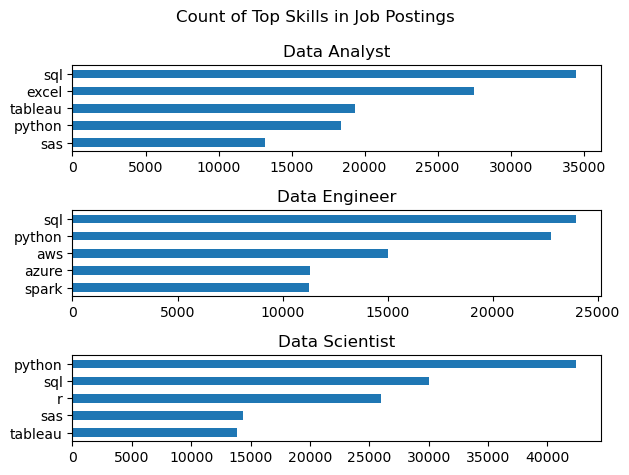

In [ ]:
# We will generate a separate bar chart for each role to show their top 5 most highly demanded skills side-by-side.
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count["job_title_short"] == job_title].head(5)
    df_plot.plot(
        kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title
    )
    ax[i].invert_yaxis()
    ax[i].legend().set_visible(False)
    ax[i].set_ylabel("")


fig.suptitle("Count of Top Skills in Job Postings")  # adding super title above all
plt.tight_layout()
plt.show()

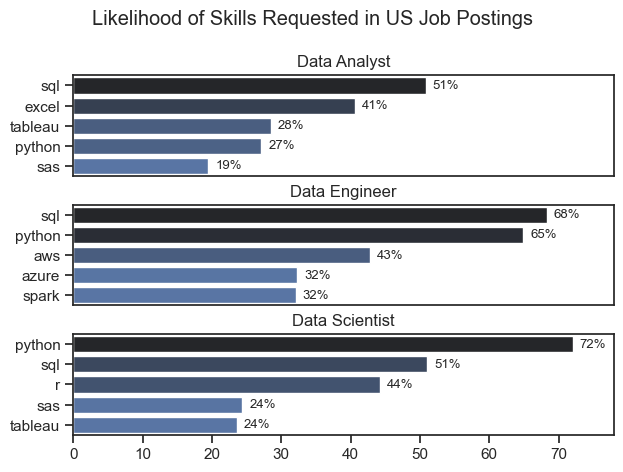

In [ ]:
# To generate a multiple stacked bar chart to visualize the top 5 most demanded skills for each of the top 3 data roles.
# This allows us to easily compare the core skill sets required across different career paths.

fig, ax = plt.subplots(len(job_titles), 1)
sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent["job_title_short"] == job_title].head(
        5
    )
    sns.barplot(
        data=df_plot,
        x="skill_percent",
        y="job_skills",
        ax=ax[i],
        hue="skill_percent",
        palette="dark:b_r",
    )

    ax[i].set_title(job_title)
    ax[i].get_legend().remove()
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")
    ax[i].set_xlim(
        0, 78
    )  # To standardize the x-axis so the bar lengths are visually comparable

    # Adding the exact percentage as a text label next to each bar for easy reading
    for n, value in enumerate(df_plot["skill_percent"]):
        ax[i].text(value + 1, n, f"{value:.0f}%", va="center", fontsize=9.5)

    # Hiding the x-axis tick marks for all but keeping for the bottom chart to keep the visual clean
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

# Adding a main title for the entire figure
fig.suptitle(
    "Likelihood of Skills Requested in US Job Postings"
)  # adding super title above all
plt.tight_layout(h_pad=0.5)  # to fix the overloop
plt.show()

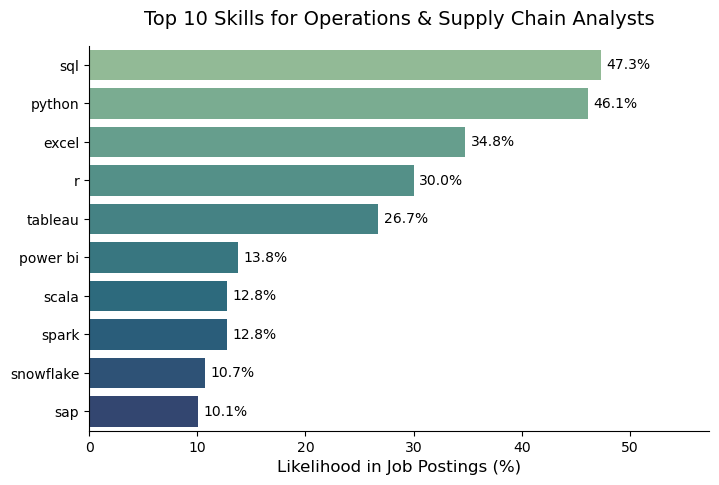

In [18]:
# To Visualize the top 10 skills specifically requested in Operations and Supply Chain analytics roles.

# Isolating job postings that specifically mention Operations, Supply Chain, and Logistics Roles using string matching
ops_keywords = "operation | supply chain | logistic"
df_ops = df_US[
    df_US["job_title"].str.contains(ops_keywords, case=False, na=False)
].copy()

# Exploding the skills column to count individual skills
df_ops_skills = df_ops.explode("job_skills")
ops_skill_counts = df_ops_skills["job_skills"].value_counts().head(10).reset_index()
ops_skill_counts.columns = ["skill", "count"]

# Calculating the percentage based on the total number of operations jobs
total_ops_jobs = len(df_ops)
ops_skill_counts["percentage"] = (ops_skill_counts["count"] / total_ops_jobs) * 100

# 3. Ploting the horizontal bargraph
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ops_skill_counts,
    x="percentage",
    y="skill",
    hue="skill",
    palette="crest",
    legend=False,
)

sns.despine()
plt.title("Top 10 Skills for Operations & Supply Chain Analysts", fontsize=14, pad=15)
plt.xlabel("Likelihood in Job Postings (%)", fontsize=12)
plt.ylabel("")

# Add percentage labels on the bars
for index, value in enumerate(ops_skill_counts["percentage"]):
    plt.text(value + 0.5, index, f"{value:.1f}%", va="center", fontsize=10)

plt.xlim(0, max(ops_skill_counts["percentage"]) + 10)
plt.show()

### 💡 Market Insight:

When we filter specifically for data roles embedded within Operations, Logistics, and Supply Chain departments, the skill priorities shift slightly compared to general tech roles. While foundational tools like SQL and Python remain critical for data processing, we often see a much heavier reliance on Excel and business intelligence tools like Power BI. This reflects the reality of the role: Operations Analysts aren't just building pipelines; they are actively building dashboards and financial models to communicate supply chain metrics to non-technical stakeholders.
